In [1]:
# Step 1:  Apply LIME to Random Forest model
# LIME = Local Interpretable Model-Agnostic Explanations
# explains ONE specific prediction at a time perturbs input and observes changes

import numpy as np
import pandas as pd
import lime.lime_tabular
import joblib
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [3]:
# Step 2: Load data and model
print("Loading data and model...")

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"


# Load saved files
X_train = np.load(save_path + "X_train.npy")
X_test = np.load(save_path + "X_test.npy")
y_train = pd.read_csv(save_path + "y_train.csv").squeeze()
y_test = pd.read_csv(save_path + "y_test.csv").squeeze()

# Load trained RF model
rf_model = joblib.load(save_path + "rf_model.joblib")

# Get class names
class_names = list(y_train.unique())
class_names.sort()

print(f"X_train: {X_train.shape}")
print(f"X_trest: {X_test.shape}")
print(f"Classes: {class_names}")
print("Data and model loaded!")

Loading data and model...
X_train: (1979513, 80)
X_trest: (848363, 80)
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack']
Data and model loaded!


In [6]:
# Step 3: Create LIME explainer
import glob

# Get feature names
path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/cicids_db/*.csv"
files = glob.glob(path)
df_sample = pd.read_csv(files[0], nrows=5)
df_sample.columns = df_sample.columns.str.strip()

non_numeric = ['Flow ID', 'Source IP',
               'Destination IP', 'Timestamp',
               'Label']
feature_names = [c for c in df_sample.columns
                if c not in non_numeric]
print(f"Features: {len(feature_names)}")

# Create LIME explainer
# TebularExplainer = for tabular/CSV data
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

print("LIME explainer created!")


Features: 80
LIME explainer created!


In [10]:
# Step 4: Explain one prediction with LIME
# LIME explain ONE specific instance 
# "Why did model predict DDOS for THIS traffic?"

print("Generating LIME explanation...")
print("This takes 1-2 minutes per instance...")

import time 
start_time = time.time()

# Pick one test sample 
# Let's explain instance index 0
instance = X_test[0]
true_label = y_test.iloc[0]

print(f"True label: {true_label}")
print(f"Predicted: {rf_model.predict([instance])[0]}")

# Generate LIME explanation
# num_features = show top 10 features
# num_samples = 1000 perturbations
explanation = explainer.explain_instance(
    instance,
    rf_model.predict_proba,
    num_features=10,
    num_samples=1000
)

end_time = time.time()
lime_time =round(end_time - start_time, 2)

print(f"LIME explaination complete!")
print(f"Time taken: {lime_time} seconds")
      

Generating LIME explanation...
This takes 1-2 minutes per instance...
True label: BENIGN


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished


Predicted: BENIGN


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


LIME explaination complete!
Time taken: 1.26 seconds


Generating LIME plot...


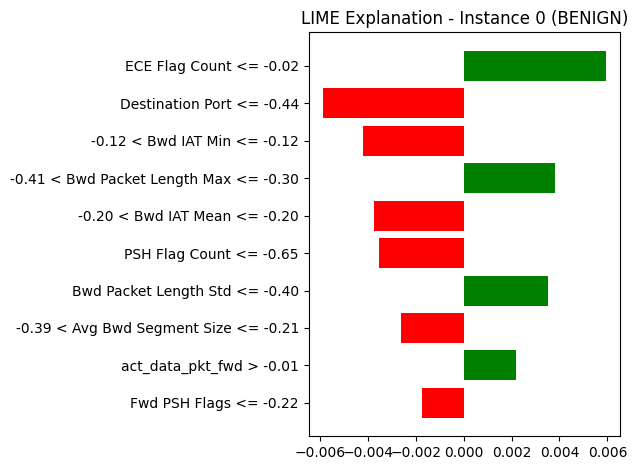

LIME plot saved!

Top 10 features for this prediction:
 ECE Flag Count <= -0.02: 0.0059
 Destination Port <= -0.44: -0.0059
 -0.12 < Bwd IAT Min <= -0.12: -0.0042
 -0.41 < Bwd Packet Length Max <= -0.30: 0.0038
 -0.20 < Bwd IAT Mean <= -0.20: -0.0037
 PSH Flag Count <= -0.65: -0.0035
 Bwd Packet Length Std <= -0.40: 0.0035
 -0.39 < Avg Bwd Segment Size <= -0.21: -0.0026
 act_data_pkt_fwd > -0.01: 0.0022
 Fwd PSH Flags <= -0.22: -0.0017


In [11]:
# Step 5: Visualize LIME explanation
# Shows which features pushed prediction toward BENIGN or away from it

print("Generating LIME plot...")

# Save as image
fig = explanation.as_pyplot_figure()
plt.title("LIME Explanation - Instance 0 (BENIGN)")
plt.tight_layout()
plt.savefig(save_path + "lime_explanation.png",
           dpi=150, bbox_inches='tight')
plt.show()
print("LIME plot saved!")

# Also print text explanation
print("\nTop 10 features for this prediction:")
for feature, weight in explanation.as_list():
    print(f" {feature}: {weight:.4f}")
    

In [15]:
# Step 6: Explain a DDoS attack instance 
# Find a DDoS sample in test set 

ddos_idx = y_test[y_test == 2].index[0]
ddos_position = y_test.index.get_loc(ddos_idx)

instance_ddos = X_test[ddos_position]
true_label_ddos = y_test.iloc[ddos_position]

print(f"True label: {true_label_ddos}")
print(f"Predicted: {rf_model.predict([instance_ddos])[0]}")

# Generate LIME explanation for DDoS
explanation_ddos = explainer.explain_instance(
    instance_ddos,
    rf_model.predict_proba,
    num_features=10,
    num_samples=1000
)

print("LIME DDoS explanation complete!")
print("\nTop 10 features for DDoS prediction:")
for feature, weight in explanation_ddos.as_list():
    print(f" {feature}: {weight:.4f}")


True label: DDoS
Predicted: DDoS


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


LIME DDoS explanation complete!

Top 10 features for DDoS prediction:
 -0.44 < Destination Port <= -0.44: -0.0050
 Bwd Packet Length Std <= -0.40: 0.0049
 RST Flag Count <= -0.02: 0.0041
 PSH Flag Count <= -0.65: -0.0039
 Total Length of Bwd Packets <= -0.01: -0.0038
 Fwd Packet Length Mean <= -0.28: -0.0034
 Fwd Packet Length Max <= -0.28: -0.0033
 Bwd IAT Mean <= -0.20: 0.0031
 ECE Flag Count <= -0.02: 0.0030
 Active Min > -0.10: -0.0028


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


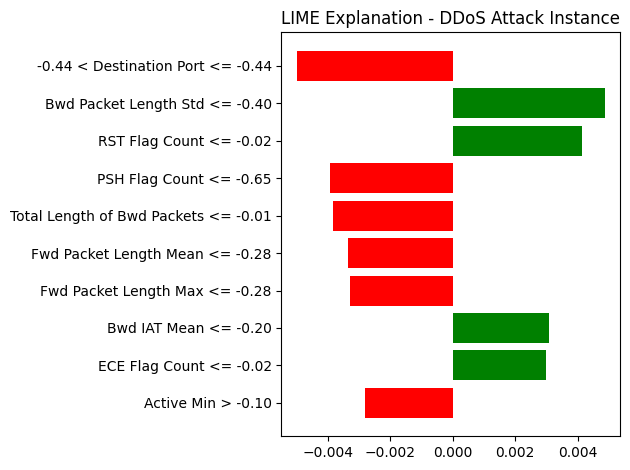

DDos LIME plot saved!


In [17]:
# Step 7: Save DDoS explanation plot
fig = explanation_ddos.as_pyplot_figure()
plt.title("LIME Explanation - DDoS Attack Instance")
plt.tight_layout()
plt.savefig(save_path + "lime_ddos.png",
           dpi=150, bbox_inches='tight')
plt.show()
print("DDos LIME plot saved!")

In [18]:
# Step 8: Save LIME results to JSON
import json

lime_results = {
    "method": "LIME",
    "model": "Random Forest",
    "dataset": "CICIDS2017",
    "instance_0":{
        "true_label": "BENIGN",
        "predicted": "BENIGN",
        "time_seconds": lime_time,
        "top_features": explanation.as_list()
    },
    "instance_ddos": {
        "true_label": "DDoS",
        "predicted": "DDoS",
        "top_features": explanation_ddos.as_list()
    }
}

with open(save_path + "lime_results.json", "w") as f:
    json.dump(lime_results,f,indent=4)

print("LIME, results saved!")

LIME, results saved!
